# Analisis Deteksi Anomali Menggunakan Isolation Forest, Local Outlier Factor (LOF), dan DBSCAN: Studi Kasus Indeks Standar Pencemaran Udara (ISPU) DKI Jakarta 2010–2021

---

| **Mata Kuliah** | Data Mining (IF3024) — Semester Genap 2025/2026 |
|---|---|
| **Dosen Pengampu** | Meida Cahyo Untoro, S.Kom., M.Kom. |
| **Kelompok** | Anomaly Detection |
| **Topik** | Topik 3 — Anomaly Detection |

### Penulis

| No | NIM | Nama Lengkap | Kontribusi |
|----|-----|-------------|-----------|
| 1 | 123140062 | Nabila Ramadhani M | Metodologi, EDA (10%) |
| 2 | 123140071 | Willy Syifa Luthfia | Hasil & Pembahasan (10%) |
| 3 | 123140121 | Fanisa Aulia Safitri | Kesimpulan, Saran, Referensi (10%) |
| 4 | 123140070 | Annisa Salsabila | Implementasi DBSCAN & Consensus Voting (10%) |
| 5 | 123140044 | Jesika Filosovi Br P-A | Implementasi Isolation Forest & LOF (10%) |
| 6 | 123140188 | Taufik Hidayat NST | Pendahuluan, Tinjauan Pustaka (15%) |
| 7 | 123140043 | Tengku Hafid Diraputra | Coding Pembuatan Notebook, Pengujian Model & Testing Pipeline (35%) |

**Tanggal:** April 2026

---

## Abstrak

Deteksi anomali merupakan tahap penting dalam preprocessing data untuk mengidentifikasi observasi yang menyimpang secara signifikan dari pola umum dataset. Penelitian ini mengevaluasi tiga metode deteksi anomali  Isolation Forest, Local Outlier Factor (LOF), dan DBSCAN  pada dataset Indeks Standar Pencemaran Udara (ISPU) DKI Jakarta tahun 2010–2021 (5.533 rekaman dari 5 stasiun pemantauan). Pipeline bebas data leakage diterapkan: train-test split (80:20, stratified) dilakukan terlebih dahulu sebelum seluruh proses preprocessing dan deteksi anomali. Parameter contamination diestimasi via aturan 3-sigma; parameter eps DBSCAN ditentukan melalui k-distance plot pada data yang direduksi PCA 2 komponen. Consensus voting (threshold ≥ 2/3 metode) digunakan untuk mengidentifikasi anomali yang robust. Evaluasi dilakukan dengan membandingkan performa Random Forest sebelum dan sesudah pembersihan anomali menggunakan Accuracy, Precision, Recall, F1-Score, dan AUC-ROC. Kualitas udara dikategorikan menjadi dua kelas: Normal (BAIK/SEDANG) dan Tidak Sehat (TIDAK SEHAT/SANGAT TIDAK SEHAT/BERBAHAYA). Hasil menunjukkan bahwa ketiga metode menangkap aspek anomali polutan udara yang berbeda; consensus voting menghasilkan deteksi yang lebih konservatif dan mengurangi false positive.

**Kata Kunci:** anomaly detection, Isolation Forest, Local Outlier Factor, DBSCAN, consensus voting, kualitas udara, ISPU Jakarta, preprocessing, data leakage


# BAB 1. PENDAHULUAN

## 1.1 Latar Belakang

Kualitas udara merupakan salah satu indikator kritis kesehatan lingkungan yang berdampak langsung pada kesehatan masyarakat. Pemerintah DKI Jakarta melalui Dinas Lingkungan Hidup memantau Indeks Standar Pencemaran Udara (ISPU) secara harian di lima stasiun pemantauan yang tersebar di wilayah Jakarta. ISPU mengukur konsentrasi lima parameter polutan utama: PM10 (partikulat ≤10 µm), SO₂ (sulfur dioksida), CO (karbon monoksida), O₃ (ozon), dan NO₂ (nitrogen dioksida).

Dalam rangka mendukung analisis dan pengambilan keputusan berbasis data pada domain lingkungan, deteksi anomali pada data kualitas udara menjadi hal yang sangat relevan. Anomali pada data ISPU dapat mengindikasikan adanya pencemaran ekstrem akibat kebakaran hutan, industri, atau kondisi meteorologi khusus yang memerlukan tindakan darurat. Sebaliknya, anomali juga dapat mengindikasikan kesalahan sensor atau data yang perlu diverifikasi.

Terdapat berbagai pendekatan deteksi anomali: tree-based (Isolation Forest), density-based (LOF), dan clustering-based (DBSCAN). Tidak ada konsensus mengenai metode tunggal yang paling robust; oleh karena itu, pendekatan ensemble atau consensus voting semakin direkomendasikan (Aggarwal, 2017). Penelitian ini mengevaluasi ketiga metode tersebut dengan pipeline yang benar (train-test split sebelum anomaly detection) untuk mencegah data leakage.

## 1.2 Rumusan Masalah

1. Bagaimana perbandingan karakteristik anomali yang terdeteksi oleh Isolation Forest, LOF, dan DBSCAN pada dataset ISPU DKI Jakarta?
2. Metode manakah yang mengidentifikasi anomali paling konsisten, dan bagaimana consensus voting meningkatkan robustness?
3. Bagaimana dampak pembersihan data anomali terhadap performa model klasifikasi kualitas udara dibandingkan baseline?

## 1.3 Tujuan Penelitian

1. Mengimplementasikan dan membandingkan Isolation Forest, LOF, dan DBSCAN untuk mendeteksi anomali dengan pipeline bebas data leakage.
2. Menerapkan consensus voting untuk mengidentifikasi anomali yang konsisten dari ketiga metode.
3. Menganalisis dampak pembersihan anomali terhadap performa klasifikasi kualitas udara dibandingkan baseline.

## 1.4 Batasan Masalah

1. Dataset: ISPU DKI Jakarta 2010–2021 dari Kaggle (senadu34/air-quality-index-in-jakarta-2010-2021).
2. Fitur: PM10, SO₂, CO, O₃, NO₂ (PM2.5 dikecualikan karena >70% missing value).
3. Target biner: 0 = Normal (BAIK/SEDANG), 1 = Tidak Sehat (TIDAK SEHAT/SANGAT TIDAK SEHAT/BERBAHAYA).
4. Metode deteksi anomali: Isolation Forest, LOF, DBSCAN.
5. Classifier evaluator: Random Forest Classifier.
6. Split: 80% training, 20% testing (stratified, dilakukan sebelum anomaly detection).
7. Metrik: Accuracy, Precision, Recall, F1-Score, AUC-ROC.
8. Threshold consensus: ≥ 2 dari 3 metode.


# BAB 2. TINJAUAN PUSTAKA

## 2.1 Data Mining dan Preprocessing

Data mining merupakan proses ekstraksi pola, hubungan, dan anomali dari kumpulan data berukuran besar untuk mendukung pengambilan keputusan berbasis data. Dalam konteks kualitas udara, data mining digunakan untuk mengidentifikasi data yang menyimpang dari pola normal, yang dapat mengindikasikan adanya kejadian pencemaran ekstrem, malfungsi sensor, atau kondisi lingkungan yang tidak biasa. Pendekatan unsupervised learning seperti Isolation Forest, Local Outlier Factor (LOF), dan DBSCAN masih banyak digunakan karena mampu mendeteksi anomali tanpa memerlukan label data (Kumari et al., 2024).

Tahap preprocessing merupakan bagian yang krusial dalam proses data mining. Pada dataset ISPU Jakarta, preprocessing mencakup penanganan missing values yang cukup signifikan (terutama PM2.5), standardisasi nilai polutan yang memiliki rentang sangat berbeda, serta imputasi nilai yang hilang menggunakan median per stasiun untuk mempertahankan konteks geografis lokal.

## 2.2 Anomaly Detection pada Data Kualitas Udara

Anomaly detection merupakan proses identifikasi pola data yang menyimpang dari perilaku normal. Pada domain kualitas udara, anomali dapat berupa: (1) **point anomaly** — nilai polutan ekstrem pada satu waktu tertentu (misal: lonjakan CO akibat kebakaran); (2) **contextual anomaly** — nilai yang normal secara global namun tidak normal pada musim/jam tertentu; (3) **collective anomaly** — pola pencemaran multi-polutan yang tidak biasa meskipun masing-masing polutan masih dalam rentang normal (Ghamry et al., 2024).

Deteksi anomali pada data lingkungan memiliki peran penting dalam sistem peringatan dini kualitas udara. Anomali yang terdeteksi dapat membantu otoritas mengidentifikasi sumber pencemaran, memvalidasi data sensor yang mungkin mengalami kerusakan, serta mendukung kebijakan pengendalian pencemaran.

## 2.3 Metode Deteksi Anomali

| Metode | Pendekatan | Prinsip Kerja | Parameter Kunci |
|--------|-----------|---------------|----------------|
| Isolation Forest | Tree-based | Mengisolasi anomali via random splits — anomali memerlukan lebih sedikit split | contamination, n_estimators |
| LOF | Density-based | Bandingkan local density titik terhadap neighbor — anomali memiliki density jauh lebih rendah | n_neighbors, contamination |
| DBSCAN | Clustering | Titik yang tidak masuk cluster mana pun (noise) dianggap anomali | eps, min_samples |

**Isolation Forest** bekerja berdasarkan prinsip bahwa anomali lebih mudah diisolasi melalui random partitioning (Liu et al., 2008). Anomaly score dihitung berdasarkan rata-rata path length terhadap expected path length.

**LOF** mengukur tingkat isolasi berdasarkan perbandingan local reachability density terhadap neighbor-nya (Breunig et al., 2000). LOF ≈ 1 berarti normal; LOF >> 1 mengindikasikan anomali.

**DBSCAN** membentuk cluster berdasarkan density-reachability. Titik yang tidak memiliki cukup neighbor dalam radius eps diklasifikasikan sebagai noise/anomali (Ester et al., 1996).

## 2.4 Consensus Voting

Consensus voting menggabungkan hasil deteksi beberapa metode untuk meningkatkan robustness dan mengurangi false positive (Aggarwal, 2017). Sebuah sampel dianggap anomali jika terdeteksi oleh ≥ 2 dari 3 metode. Anomali genuine cenderung terdeteksi oleh berbagai metode meskipun pendekatannya berbeda, sedangkan false positive dari satu metode cenderung tidak dikonfirmasi metode lain.

## 2.5 Metrik Evaluasi

- **Accuracy:** Proporsi prediksi benar dari total prediksi.
- **Precision (macro):** TP/(TP+FP) — ketepatan prediksi positif.
- **Recall (macro):** TP/(TP+FN) — seberapa banyak positif terdeteksi.
- **F1-Score (macro):** Harmonic mean Precision dan Recall.
- **AUC-ROC:** Area di bawah kurva ROC — kemampuan diskriminasi model.
- **Confusion Matrix:** Matriks TP, TN, FP, FN.


In [ ]:
# ============================================================
# IMPORT LIBRARY
# ============================================================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier, IsolationForest
from sklearn.neighbors import LocalOutlierFactor, NearestNeighbors
from sklearn.cluster import DBSCAN
from sklearn.decomposition import PCA
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, confusion_matrix,
    ConfusionMatrixDisplay, RocCurveDisplay, classification_report
)

plt.rcParams['figure.dpi'] = 100
plt.rcParams['font.size'] = 10
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
print("✅ Semua library berhasil diimport!")


✅ Semua library berhasil diimport!


In [ ]:
# ============================================================
# LOAD DATASET
# ============================================================
# Download dari: https://www.kaggle.com/datasets/senadu34/air-quality-index-in-jakarta-2010-2021
# File: ispu_dki_all.csv

import os
if not os.path.exists('ispu_dki_all.csv'):
    print("⚠️  File ispu_dki_all.csv tidak ditemukan.")
    print("    Silakan upload terlebih dahulu:")
    print("    from google.colab import files; files.upload()")
else:
    df_raw = pd.read_csv('ispu_dki_all.csv')
    df_raw['tanggal'] = pd.to_datetime(df_raw['tanggal'])
    print(f"✅ Dataset berhasil dimuat!")
    print(f"   Ukuran  : {df_raw.shape[0]:,} baris x {df_raw.shape[1]} kolom")
    print(f"   Missing : {df_raw.isnull().sum().sum()} total")
    print(f"   Duplikat: {df_raw.duplicated().sum():,}")
    print(f"   Rentang Tanggal: {df_raw['tanggal'].min().date()} s/d {df_raw['tanggal'].max().date()}")
    print(f"\nKolom  :")
    for c in df_raw.columns:
        print(f"   {c}: {df_raw[c].dtype} | missing={df_raw[c].isnull().sum()}")


✅ Dataset berhasil dimuat!
   Ukuran  : 5,538 baris x 11 kolom
   Missing : 4771 total
   Duplikat: 0
   Rentang Tanggal: 2010-01-01 s/d 2025-02-28

Kolom  :
   tanggal: datetime64[ns] | missing=0
   stasiun: object | missing=1
   pm25: float64 | missing=4022
   pm10: float64 | missing=315
   so2: float64 | missing=130
   co: float64 | missing=88
   o3: float64 | missing=104
   no2: float64 | missing=106
   max: float64 | missing=1
   critical: object | missing=4
   categori: object | missing=0


# BAB 3. METODOLOGI PENELITIAN

## 3.1 Alur Penelitian

```
Pengumpulan Data → EDA
        ↓
Preprocessing (Cleaning, Imputasi Median, Feature Engineering)
        ↓
Train-Test Split (80:20, stratified) ← SEBELUM preprocessing scaling
        ↓
Standarisasi (fit HANYA pada train set)
        ↓
Estimasi Parameter: contamination (3-sigma) + eps DBSCAN (k-distance plot PCA)
        ↓
Deteksi Anomali pada Training Set: IF (full) + LOF (full) + DBSCAN (PCA+full)
        ↓
Consensus Voting (threshold ≥ 2/3) → Cleaning Training Set
        ↓
Training RF Baseline (train asli) vs RF Cleaned (train bersih)
        ↓
Evaluasi pada Test Set Asli → Analisis Dampak
```

## 3.2 Deskripsi Dataset

Dataset: ISPU DKI Jakarta 2010–2021 (Kaggle, senadu34/air-quality-index-in-jakarta-2010-2021)

| Atribut | Nilai |
|---------|-------|
| Jumlah sampel (setelah cleaning) | ±5.533 rekaman |
| Jumlah fitur polutan | 5 (PM10, SO₂, CO, O₃, NO₂) |
| Target biner | 0=Normal (BAIK/SEDANG), 1=Tidak Sehat |
| Stasiun | 5 stasiun (DKI1–DKI5) |
| Rentang waktu | Januari 2010 – Februari 2021 |
| Missing Values | PM2.5: >70% (dikecualikan), polutan lain: imputasi median |

## 3.3 Prosedur Eksperimen

- **Preprocessing:** Drop kategori 'TIDAK ADA DATA'; drop baris stasiun NaN; imputasi median per stasiun pada PM10, SO₂, CO, O₃, NO₂; buat fitur biner target dari kolom 'categori'
- **Train-Test Split:** 80:20, stratified sebelum scaling (mencegah data leakage)
- **Standarisasi:** Fitur polutan di-scale menggunakan StandardScaler (fit hanya pada train)
- **Contamination:** Estimasi 3-sigma pada training set
- **Isolation Forest:** n_estimators=100, pada seluruh training set
- **LOF:** n_neighbors=20, pada seluruh training set (dataset cukup kecil ~4.400 baris)
- **DBSCAN:** eps dari k-distance plot (PCA 2 komponen), min_samples=5
- **Consensus:** Threshold ≥ 2/3 metode
- **Evaluasi:** Random Forest (n_estimators=100) pada test set asli


# BAB 4. HASIL DAN PEMBAHASAN

## 4.1 Eksplorasi Data (EDA)

### 4.1.1 Gambaran Umum Dataset


In [ ]:
# ============================================================
# 4.1.1 STATISTIK DESKRIPTIF
# ============================================================
# Preprocessing awal untuk EDA
df = df_raw.copy()
df = df[~df['categori'].isin(['TIDAK ADA DATA'])].copy()
df = df.dropna(subset=['stasiun']).copy()
df = df.reset_index(drop=True)

FEATURE_COLS = ['pm10', 'so2', 'co', 'o3', 'no2']

print("=" * 65)
print("STATISTIK DESKRIPTIF DATASET ISPU DKI JAKARTA")
print("=" * 65)
print(f"\nJumlah sampel  : {df.shape[0]:,}")
print(f"Jumlah fitur   : {len(FEATURE_COLS)} polutan ({', '.join(FEATURE_COLS).upper()})")
print(f"Stasiun        : {df['stasiun'].nunique()} stasiun")
print(f"Rentang waktu  : {df['tanggal'].min().date()} s/d {df['tanggal'].max().date()}")
print(f"\nMissing values per kolom fitur:")
for c in FEATURE_COLS:
    pct = df[c].isnull().sum() / len(df) * 100
    print(f"  {c.upper():<8}: {df[c].isnull().sum():>5} ({pct:.2f}%)")

print("\nStatistik ringkas fitur polutan:")
display(df[FEATURE_COLS].describe().round(2))


STATISTIK DESKRIPTIF DATASET ISPU DKI JAKARTA

Jumlah sampel  : 5,533
Jumlah fitur   : 5 polutan (PM10, SO2, CO, O3, NO2)
Stasiun        : 5 stasiun
Rentang waktu  : 2010-01-01 s/d 2025-02-28

Missing values per kolom fitur:
  PM10    :   311 (5.62%)
  SO2     :   126 (2.28%)
  CO      :    84 (1.52%)
  O3      :   100 (1.81%)
  NO2     :   102 (1.84%)

Statistik ringkas fitur polutan:


,pm10,so2,co,o3,no2
count,5222.00,5407.00,5449.00,5433.00,5431.00
mean,56.41,22.43,20.42,77.47,14.34
std,20.01,15.45,11.96,51.80,10.04
min,2.00,0.00,0.00,4.00,1.00
25%,45.00,10.00,12.00,36.00,8.00
50%,57.00,18.00,18.00,69.00,12.00
75%,67.00,32.00,26.00,103.00,18.00
max,187.00,112.00,119.00,314.00,202.00


### 4.1.2 Distribusi Kategori Kualitas Udara

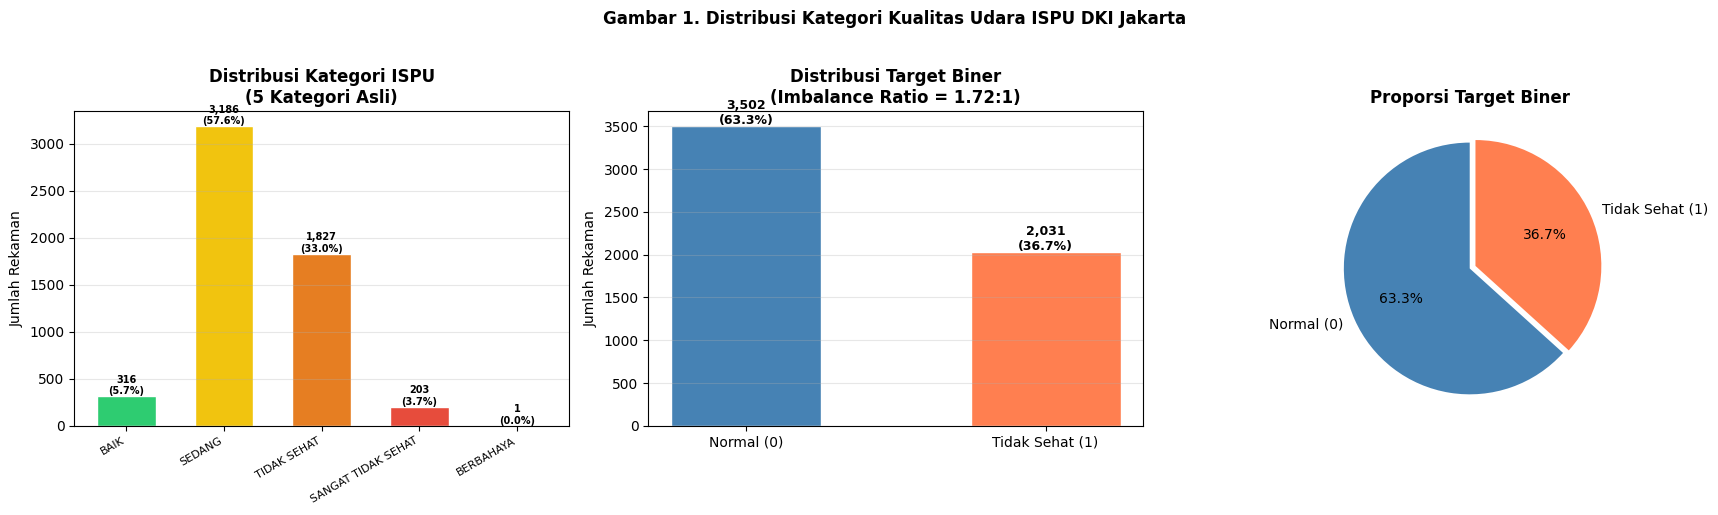

Normal (0)     : 3,502 (63.29%) — BAIK + SEDANG
Tidak Sehat (1): 2,031 (36.71%) — TIDAK SEHAT + SANGAT TIDAK SEHAT + BERBAHAYA
Imbalance Ratio: 1.72:1  (lebih seimbang dibanding dataset fraud)


In [ ]:
# ============================================================
# 4.1.2 DISTRIBUSI KATEGORI KUALITAS UDARA
# ============================================================
cat_order = ['BAIK', 'SEDANG', 'TIDAK SEHAT', 'SANGAT TIDAK SEHAT', 'BERBAHAYA']
cat_colors = ['#2ecc71', '#f1c40f', '#e67e22', '#e74c3c', '#8e44ad']
cat_counts = df['categori'].value_counts().reindex(cat_order, fill_value=0)

# Buat label biner
def make_binary(cat):
    if cat in ['BAIK', 'SEDANG']:
        return 0
    else:
        return 1

df['target'] = df['categori'].apply(make_binary)
class_counts = df['target'].value_counts().sort_index()
ir = class_counts[0] / class_counts[1]

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Bar kategori asli
bars = axes[0].bar(range(len(cat_order)), cat_counts.values,
                   color=cat_colors, edgecolor='white', width=0.6)
axes[0].set_xticks(range(len(cat_order)))
axes[0].set_xticklabels(cat_order, rotation=30, ha='right', fontsize=8)
axes[0].set_title('Distribusi Kategori ISPU\n(5 Kategori Asli)', fontweight='bold')
axes[0].set_ylabel('Jumlah Rekaman')
for bar, val in zip(bars, cat_counts.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 20,
                 f'{val:,}\n({val/len(df)*100:.1f}%)',
                 ha='center', fontweight='bold', fontsize=7)
axes[0].grid(axis='y', alpha=0.3)

# Bar biner
bars2 = axes[1].bar(['Normal (0)', 'Tidak Sehat (1)'], class_counts.values,
                    color=['steelblue', 'coral'], edgecolor='white', width=0.5)
axes[1].set_title(f'Distribusi Target Biner\n(Imbalance Ratio = {ir:.2f}:1)', fontweight='bold')
axes[1].set_ylabel('Jumlah Rekaman')
for bar, val in zip(bars2, class_counts.values):
    axes[1].text(bar.get_x() + bar.get_width()/2, val + 20,
                 f'{val:,}\n({val/len(df)*100:.1f}%)',
                 ha='center', fontweight='bold', fontsize=9)
axes[1].grid(axis='y', alpha=0.3)

# Pie biner
axes[2].pie(class_counts.values, labels=['Normal (0)', 'Tidak Sehat (1)'],
            autopct='%1.1f%%', colors=['steelblue', 'coral'],
            startangle=90, explode=[0, 0.05])
axes[2].set_title('Proporsi Target Biner', fontweight='bold')

plt.suptitle('Gambar 1. Distribusi Kategori Kualitas Udara ISPU DKI Jakarta',
             fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

print(f"Normal (0)     : {class_counts[0]:,} ({class_counts[0]/len(df)*100:.2f}%) — BAIK + SEDANG")
print(f"Tidak Sehat (1): {class_counts[1]:,} ({class_counts[1]/len(df)*100:.2f}%) — TIDAK SEHAT + SANGAT TIDAK SEHAT + BERBAHAYA")
print(f"Imbalance Ratio: {ir:.2f}:1  (lebih seimbang dibanding dataset fraud)")


### 4.1.3 Distribusi Fitur Polutan per Kelas

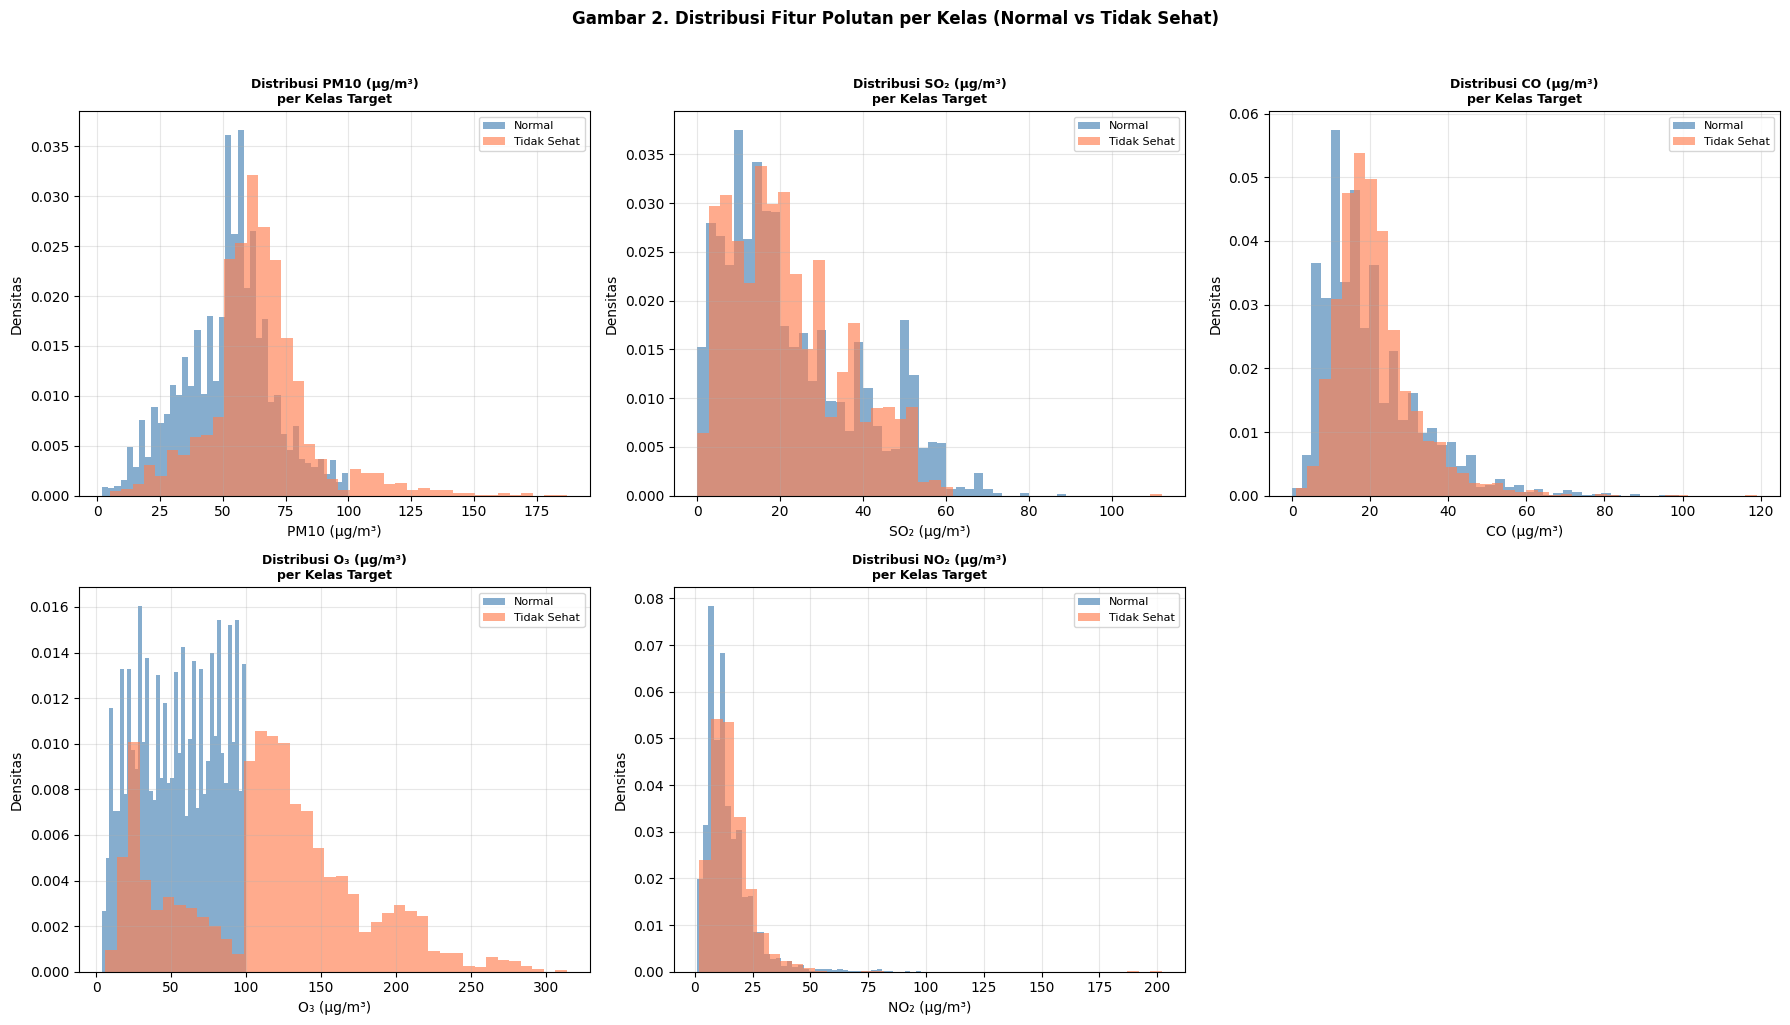

In [ ]:
# ============================================================
# 4.1.3 DISTRIBUSI FITUR POLUTAN PER KELAS
# ============================================================
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

polutan_labels = {'pm10': 'PM10 (µg/m³)', 'so2': 'SO₂ (µg/m³)',
                  'co': 'CO (µg/m³)', 'o3': 'O₃ (µg/m³)', 'no2': 'NO₂ (µg/m³)'}

for i, (col, label) in enumerate(polutan_labels.items()):
    ax = axes[i]
    for cls, color, lbl in [(0, 'steelblue', 'Normal'), (1, 'coral', 'Tidak Sehat')]:
        data = df[df['target'] == cls][col].dropna()
        ax.hist(data, bins=40, alpha=0.65, color=color, label=lbl, density=True)
    ax.set_title(f'Distribusi {label}\nper Kelas Target', fontweight='bold', fontsize=9)
    ax.set_xlabel(label); ax.set_ylabel('Densitas')
    ax.legend(fontsize=8)
    ax.grid(alpha=0.3)

axes[5].axis('off')

plt.suptitle('Gambar 2. Distribusi Fitur Polutan per Kelas (Normal vs Tidak Sehat)',
             fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()


### 4.1.4 Distribusi per Stasiun dan Tren Waktu

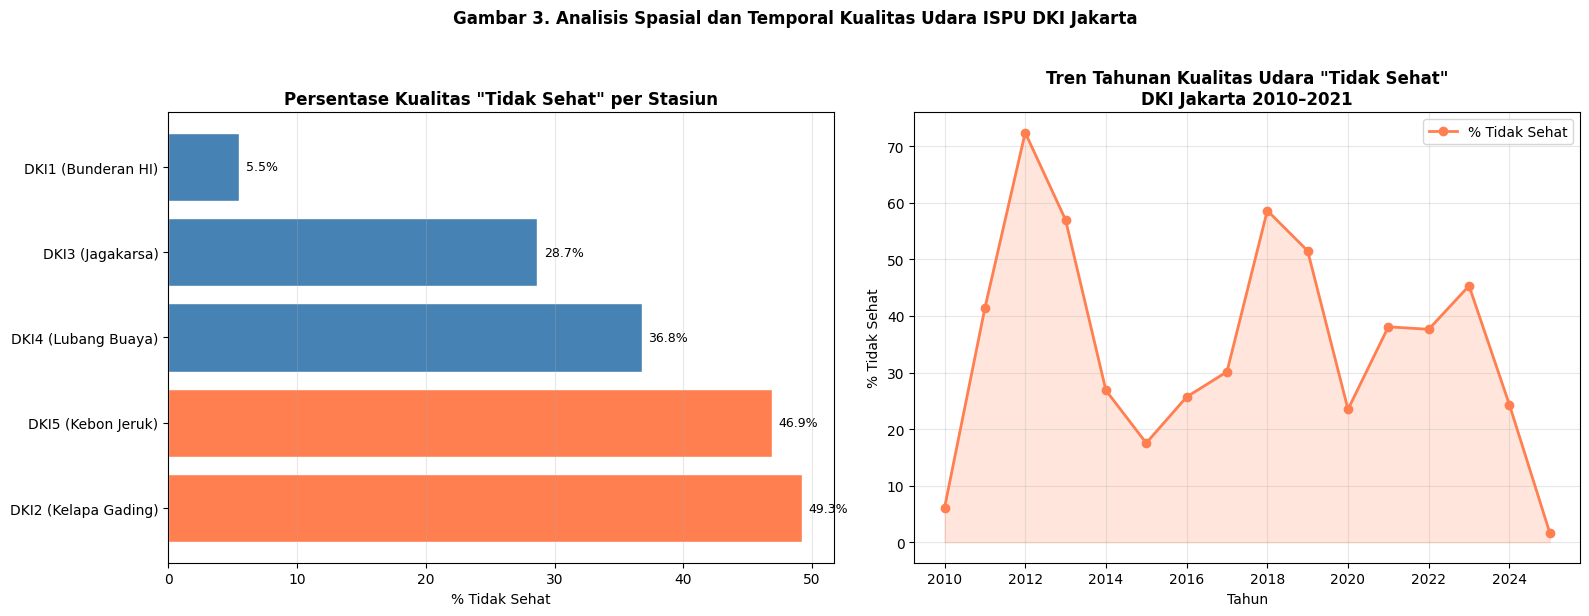

In [ ]:
# ============================================================
# 4.1.4 DISTRIBUSI KUALITAS UDARA PER STASIUN DAN TREN TAHUNAN
# ============================================================
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Distribusi per stasiun
station_target = df.groupby('stasiun')['target'].mean().sort_values(ascending=False)
colors_st = ['coral' if v > 0.4 else 'steelblue' for v in station_target.values]
axes[0].barh(station_target.index, station_target.values * 100,
             color=colors_st, edgecolor='white')
axes[0].set_title('Persentase Kualitas "Tidak Sehat" per Stasiun', fontweight='bold')
axes[0].set_xlabel('% Tidak Sehat'); axes[0].grid(axis='x', alpha=0.3)
for i, (idx, val) in enumerate(station_target.items()):
    axes[0].text(val * 100 + 0.5, i, f'{val*100:.1f}%', va='center', fontsize=9)

# Tren tahunan
df['tahun'] = df['tanggal'].dt.year
tren = df.groupby('tahun')['target'].mean() * 100
axes[1].plot(tren.index, tren.values, marker='o', color='coral',
             linewidth=2, markersize=6, label='% Tidak Sehat')
axes[1].fill_between(tren.index, tren.values, alpha=0.2, color='coral')
axes[1].set_title('Tren Tahunan Kualitas Udara "Tidak Sehat"\nDKI Jakarta 2010–2021', fontweight='bold')
axes[1].set_xlabel('Tahun'); axes[1].set_ylabel('% Tidak Sehat')
axes[1].grid(alpha=0.3); axes[1].legend()

plt.suptitle('Gambar 3. Analisis Spasial dan Temporal Kualitas Udara ISPU DKI Jakarta',
             fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()


### 4.1.5 Korelasi Antar Polutan

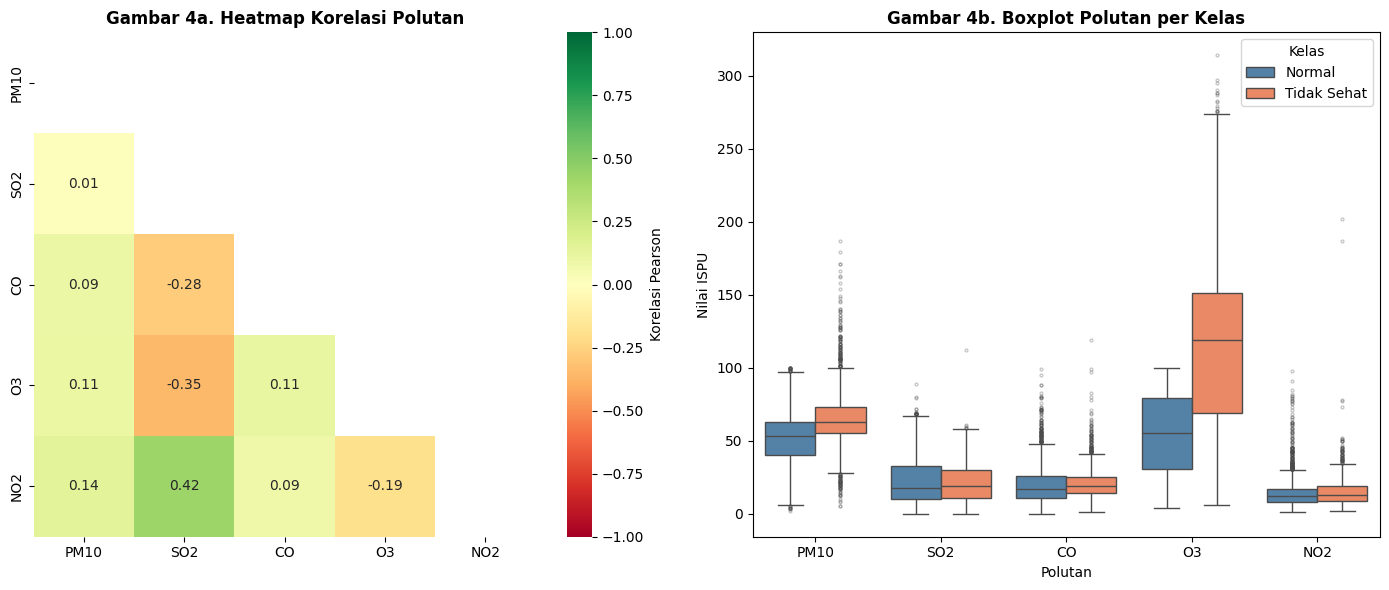

In [ ]:
# ============================================================
# 4.1.5 KORELASI ANTAR POLUTAN
# ============================================================
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

corr = df[FEATURE_COLS].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='RdYlGn',
            mask=mask, ax=axes[0], vmin=-1, vmax=1,
            cbar_kws={'label': 'Korelasi Pearson'},
            xticklabels=[c.upper() for c in FEATURE_COLS],
            yticklabels=[c.upper() for c in FEATURE_COLS])
axes[0].set_title('Gambar 4a. Heatmap Korelasi Polutan', fontweight='bold')

# Boxplot per polutan
df_melt = df[FEATURE_COLS + ['target']].melt(id_vars='target', var_name='Polutan', value_name='Nilai')
df_melt['Kelas'] = df_melt['target'].map({0: 'Normal', 1: 'Tidak Sehat'})
sns.boxplot(data=df_melt, x='Polutan', y='Nilai', hue='Kelas',
            ax=axes[1], palette={'Normal': 'steelblue', 'Tidak Sehat': 'coral'},
            showfliers=True, flierprops=dict(markersize=2, alpha=0.3))
axes[1].set_title('Gambar 4b. Boxplot Polutan per Kelas', fontweight='bold')
axes[1].set_xlabel('Polutan'); axes[1].set_ylabel('Nilai ISPU')
axes[1].set_xticklabels([c.upper() for c in FEATURE_COLS])

plt.tight_layout()
plt.show()


## 4.2 Preprocessing dan Train-Test Split

In [ ]:
# ============================================================
# 4.2 PREPROCESSING
# ============================================================

# 1. Imputasi median per stasiun
df_clean = df.copy()
for col in FEATURE_COLS:
    df_clean[col] = df_clean.groupby('stasiun')[col].transform(
        lambda x: x.fillna(x.median())
    )
    # Fallback: jika masih ada NaN (stasiun hanya punya NaN), isi dengan median global
    df_clean[col] = df_clean[col].fillna(df_clean[col].median())

print("Missing values setelah imputasi:")
print(df_clean[FEATURE_COLS].isnull().sum())

# 2. Siapkan X dan y
X_all = df_clean[FEATURE_COLS].values
y_all = df_clean['target'].values

print(f"\nUkuran dataset final: {X_all.shape[0]:,} sampel x {X_all.shape[1]} fitur")
print(f"Distribusi kelas: Normal={y_all.sum()==0} → 0={int((y_all==0).sum())}, 1={int((y_all==1).sum())}")

# 3. Train-Test Split (SEBELUM scaling — mencegah data leakage)
X_train_raw, X_test_raw, y_train_np, y_test_np = train_test_split(
    X_all, y_all, test_size=0.2, random_state=RANDOM_STATE, stratify=y_all
)

print(f"\nTrain-Test Split (80:20, stratified):")
print(f"  Training set : {X_train_raw.shape[0]:,} sampel | target 1: {y_train_np.sum()}")
print(f"  Test set     : {X_test_raw.shape[0]:,} sampel | target 1: {y_test_np.sum()}")

# 4. Standarisasi (fit HANYA pada train)
scaler = StandardScaler()
X_train_np = scaler.fit_transform(X_train_raw)
X_test_np  = scaler.transform(X_test_raw)

N_TRAIN = X_train_np.shape[0]
print(f"\n✅ Standarisasi selesai (fit hanya pada {N_TRAIN:,} sampel training).")


Missing values setelah imputasi:
pm10    0
so2     0
co      0
o3      0
no2     0
dtype: int64

Ukuran dataset final: 5,533 sampel x 5 fitur
Distribusi kelas: Normal=False → 0=3502, 1=2031

Train-Test Split (80:20, stratified):
  Training set : 4,426 sampel | target 1: 1625
  Test set     : 1,107 sampel | target 1: 406

✅ Standarisasi selesai (fit hanya pada 4,426 sampel training).


## 4.3 Estimasi Parameter Deteksi Anomali

In [ ]:
# ============================================================
# 4.3.1 ESTIMASI CONTAMINATION (3-SIGMA RULE)
# ============================================================
from scipy import stats

z_scores_train = np.abs(stats.zscore(X_train_np))
outlier_mask_3sigma = (z_scores_train > 3).any(axis=1)
CONTAMINATION = max(0.01, min(0.10, round(outlier_mask_3sigma.mean(), 4)))

print("=" * 55)
print("ESTIMASI CONTAMINATION (3-SIGMA RULE)")
print("=" * 55)
print(f"Sampel training     : {N_TRAIN:,}")
print(f"Sampel outlier (3σ) : {outlier_mask_3sigma.sum():,}")
print(f"Proporsi (%)        : {outlier_mask_3sigma.mean()*100:.4f}%")
print(f"CONTAMINATION       : {CONTAMINATION}")


ESTIMASI CONTAMINATION (3-SIGMA RULE)
Sampel training     : 4,426
Sampel outlier (3σ) : 246
Proporsi (%)        : 5.5581%
CONTAMINATION       : 0.0556


PCA 2 komponen — Explained variance: 58.02%


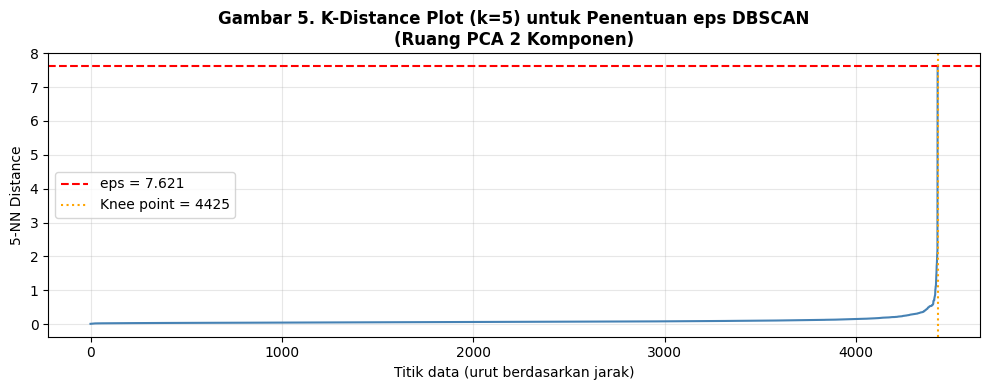

eps optimal DBSCAN: 7.621


In [ ]:
# ============================================================
# 4.3.2 K-DISTANCE PLOT UNTUK EPS DBSCAN (PCA 2 KOMPONEN)
# ============================================================
N_PCA_DB   = 2
MIN_SAMPLES_DBSCAN = 5

pca_db = PCA(n_components=N_PCA_DB, random_state=RANDOM_STATE)
X_pca_db = pca_db.fit_transform(X_train_np)
print(f"PCA {N_PCA_DB} komponen — Explained variance: {pca_db.explained_variance_ratio_.sum():.2%}")

nbrs = NearestNeighbors(n_neighbors=MIN_SAMPLES_DBSCAN).fit(X_pca_db)
distances, _ = nbrs.kneighbors(X_pca_db)
k_dist = np.sort(distances[:, -1])

# Tentukan eps otomatis: titik kelengkungan maksimum (kneighbors ke-k)
knee_idx = np.argmax(np.gradient(np.gradient(k_dist)))
eps_optimal = round(float(k_dist[knee_idx]), 3)

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(k_dist, linewidth=1.5, color='steelblue')
ax.axhline(y=eps_optimal, color='red', linestyle='--', linewidth=1.5,
           label=f'eps = {eps_optimal}')
ax.axvline(x=knee_idx, color='orange', linestyle=':', linewidth=1.5,
           label=f'Knee point = {knee_idx}')
ax.set_title(f'Gambar 5. K-Distance Plot (k={MIN_SAMPLES_DBSCAN}) untuk Penentuan eps DBSCAN\n(Ruang PCA {N_PCA_DB} Komponen)',
             fontweight='bold')
ax.set_xlabel('Titik data (urut berdasarkan jarak)')
ax.set_ylabel(f'{MIN_SAMPLES_DBSCAN}-NN Distance')
ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

print(f"eps optimal DBSCAN: {eps_optimal}")


## 4.4 Deteksi Anomali

### 4.4.1 Isolation Forest

In [ ]:
# ============================================================
# 4.4.1 ISOLATION FOREST (Full Training Set)
# ============================================================
print("Menjalankan Isolation Forest pada seluruh training set...")

iso_forest = IsolationForest(
    n_estimators=100,
    contamination=CONTAMINATION,
    random_state=RANDOM_STATE,
    n_jobs=-1
)
iso_forest.fit(X_train_np)
pred_if = iso_forest.predict(X_train_np)   # 1=normal, -1=anomali
lbl_if  = (pred_if == -1).astype(int)      # 1=anomali

print(f"✅ Isolation Forest selesai.")
print(f"   Anomali terdeteksi: {lbl_if.sum():,} ({lbl_if.mean()*100:.3f}%)")


Menjalankan Isolation Forest pada seluruh training set...
✅ Isolation Forest selesai.
   Anomali terdeteksi: 247 (5.581%)


### 4.4.2 Local Outlier Factor (LOF)

In [ ]:
# ============================================================
# 4.4.2 LOCAL OUTLIER FACTOR (Full Training Set)
# ============================================================
print("Menjalankan LOF pada seluruh training set...")

lof = LocalOutlierFactor(
    n_neighbors=20,
    contamination=CONTAMINATION,
    n_jobs=-1
)
pred_lof = lof.fit_predict(X_train_np)    # 1=normal, -1=anomali
lbl_lof  = (pred_lof == -1).astype(int)  # 1=anomali

print(f"✅ LOF selesai.")
print(f"   Anomali terdeteksi: {lbl_lof.sum():,} ({lbl_lof.mean()*100:.3f}%)")


Menjalankan LOF pada seluruh training set...
✅ LOF selesai.
   Anomali terdeteksi: 247 (5.581%)


### 4.4.3 DBSCAN

In [ ]:
# ============================================================
# 4.4.3 DBSCAN (Pada Ruang PCA 2 Komponen)
# ============================================================
print("Menjalankan DBSCAN pada ruang PCA 2 komponen...")

dbscan = DBSCAN(eps=eps_optimal, min_samples=MIN_SAMPLES_DBSCAN, n_jobs=-1)
pred_db = dbscan.fit_predict(X_pca_db)   # -1=noise/anomali
lbl_db  = (pred_db == -1).astype(int)   # 1=anomali

n_clusters = len(set(pred_db)) - (1 if -1 in pred_db else 0)
print(f"✅ DBSCAN selesai.")
print(f"   Jumlah cluster    : {n_clusters}")
print(f"   Anomali (noise)   : {lbl_db.sum():,} ({lbl_db.mean()*100:.3f}%)")


Menjalankan DBSCAN pada ruang PCA 2 komponen...
✅ DBSCAN selesai.
   Jumlah cluster    : 1
   Anomali (noise)   : 0 (0.000%)


### 4.4.4 Ringkasan Deteksi dan Visualisasi PCA 2D


Tabel 1. Ringkasan Jumlah Anomali per Metode Deteksi (pada Training Set)


,Metode,Sampel Diproses,Anomali Terdeteksi,Persentase (%),Parameter Kunci
0,Isolation Forest,"4,426",247,5.581%,"contamination=0.0556, n_estimators=100"
1,LOF,"4,426",247,5.581%,"n_neighbors=20, contamination=0.0556"
2,DBSCAN,"4,426",0,0.000%,"eps=7.621 (PCA-2), min_samples=5"



Explained variance (2 komponen): 58.02%


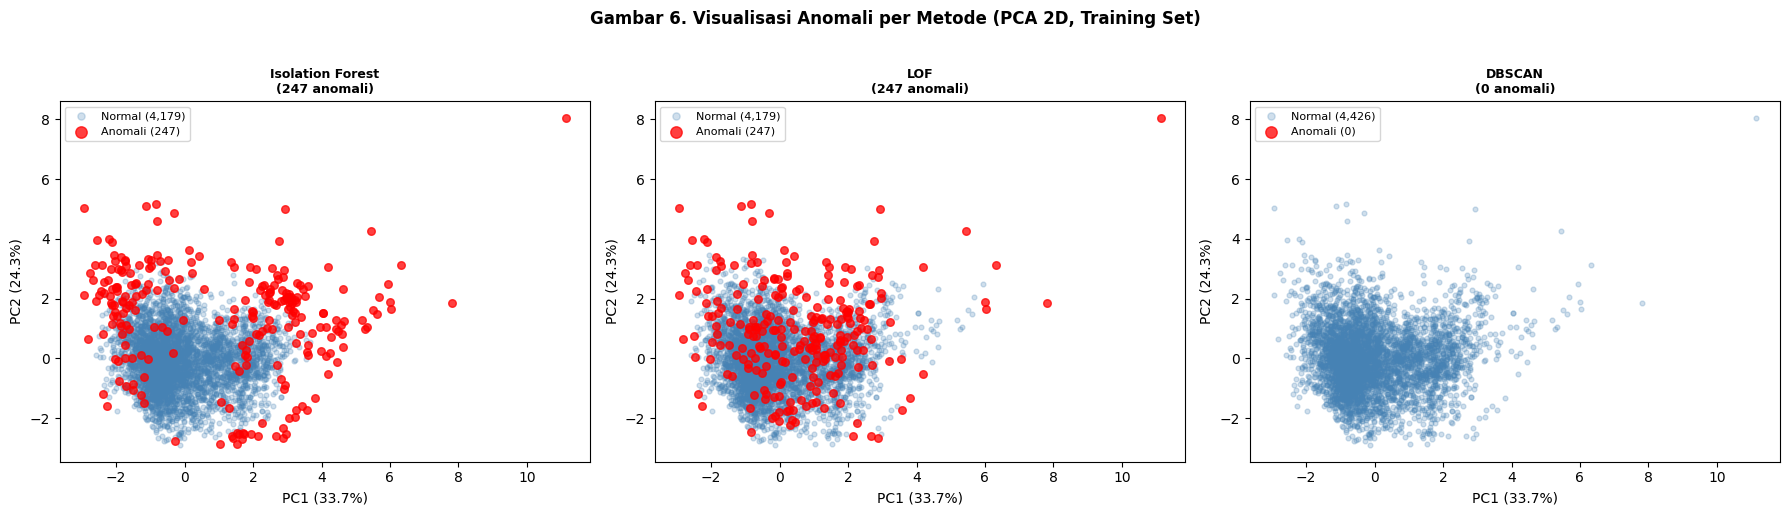

In [ ]:
# ============================================================
# 4.4.4 RINGKASAN + VISUALISASI PCA 2D
# ============================================================

# Tabel ringkasan
summary_det = pd.DataFrame({
    'Metode'             : ['Isolation Forest', 'LOF', 'DBSCAN'],
    'Sampel Diproses'    : [f"{N_TRAIN:,}", f"{N_TRAIN:,}", f"{N_TRAIN:,}"],
    'Anomali Terdeteksi' : [f"{lbl_if.sum():,}", f"{lbl_lof.sum():,}", f"{lbl_db.sum():,}"],
    'Persentase (%)'     : [f"{lbl_if.mean()*100:.3f}%",
                             f"{lbl_lof.mean()*100:.3f}%",
                             f"{lbl_db.mean()*100:.3f}%"],
    'Parameter Kunci'    : [
        f"contamination={CONTAMINATION}, n_estimators=100",
        f"n_neighbors=20, contamination={CONTAMINATION}",
        f"eps={eps_optimal} (PCA-{N_PCA_DB}), min_samples={MIN_SAMPLES_DBSCAN}"
    ]
})
print("\nTabel 1. Ringkasan Jumlah Anomali per Metode Deteksi (pada Training Set)")
print("=" * 100)
display(summary_det)

# Visualisasi PCA 2D
pca_viz = PCA(n_components=2, random_state=RANDOM_STATE)
X_pca2d = pca_viz.fit_transform(X_train_np)
ev_ratio = pca_viz.explained_variance_ratio_
print(f"\nExplained variance (2 komponen): {ev_ratio.sum():.2%}")

labels_dict = {
    'Isolation Forest': lbl_if,
    'LOF'             : lbl_lof,
    'DBSCAN'          : lbl_db
}

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, (name, lbl) in zip(axes, labels_dict.items()):
    for val, (color, alpha) in {0: ('steelblue', 0.25), 1: ('red', 0.75)}.items():
        mask = lbl == val
        label = f'Anomali ({mask.sum():,})' if val == 1 else f'Normal ({mask.sum():,})'
        ax.scatter(X_pca2d[mask, 0], X_pca2d[mask, 1], c=color,
                   alpha=alpha, s=12 if val==0 else 30, label=label)
    ax.set_title(f'{name}\n({(lbl==1).sum()} anomali)', fontweight='bold', fontsize=9)
    ax.set_xlabel(f'PC1 ({ev_ratio[0]:.1%})')
    ax.set_ylabel(f'PC2 ({ev_ratio[1]:.1%})')
    ax.legend(fontsize=8, markerscale=1.5)

plt.suptitle('Gambar 6. Visualisasi Anomali per Metode (PCA 2D, Training Set)',
             fontweight='bold', y=1.02)
plt.tight_layout(); plt.show()


## 4.5 Consensus Voting

RINGKASAN CONSENSUS VOTING (TRAINING SET)
Terdeteksi oleh 0 metode : 4,030
Terdeteksi oleh 1 metode : 298
Terdeteksi oleh 2 metode : 98
Terdeteksi oleh 3 metode : 0
-------------------------------------------------------
Total anomali (consensus ≥ 2) : 98 (2.2142%)
Total data normal             : 4,328


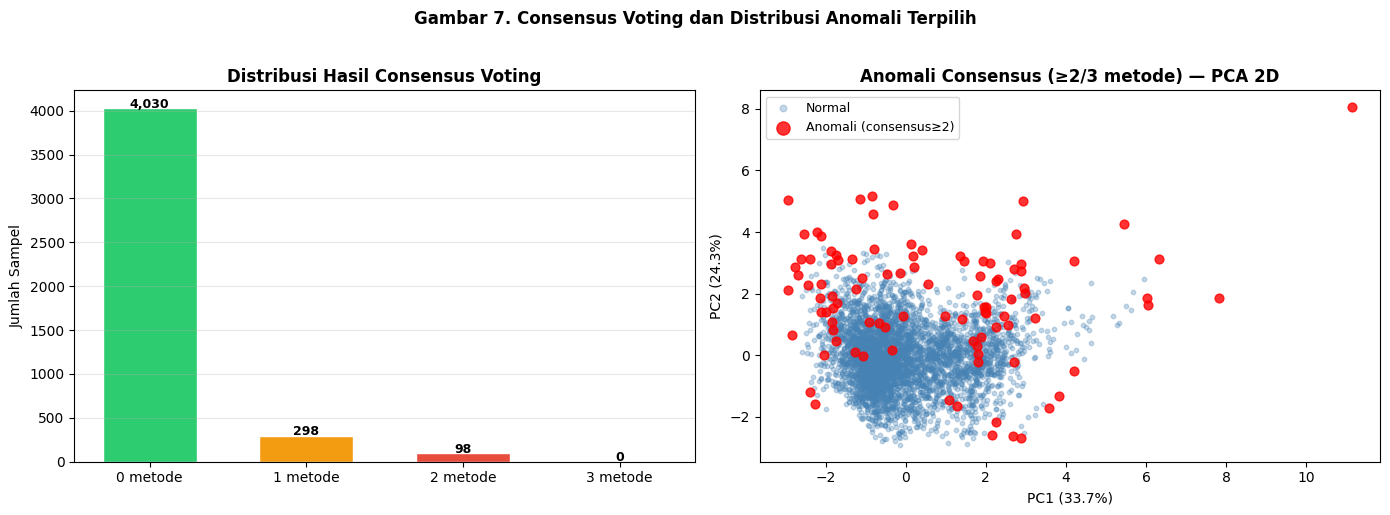

In [ ]:
# ============================================================
# 4.5 CONSENSUS VOTING (≥ 2 dari 3 metode)
# ============================================================
consensus_train = lbl_if + lbl_lof + lbl_db
anomalies_mask  = consensus_train >= 2

print("=" * 55)
print("RINGKASAN CONSENSUS VOTING (TRAINING SET)")
print("=" * 55)
print(f"Terdeteksi oleh 0 metode : {(consensus_train == 0).sum():,}")
print(f"Terdeteksi oleh 1 metode : {(consensus_train == 1).sum():,}")
print(f"Terdeteksi oleh 2 metode : {(consensus_train == 2).sum():,}")
print(f"Terdeteksi oleh 3 metode : {(consensus_train == 3).sum():,}")
print("-" * 55)
print(f"Total anomali (consensus ≥ 2) : {anomalies_mask.sum():,} ({anomalies_mask.mean()*100:.4f}%)")
print(f"Total data normal             : {(~anomalies_mask).sum():,}")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

vote_labels  = ['0 metode', '1 metode', '2 metode', '3 metode']
vote_counts  = [(consensus_train == i).sum() for i in range(4)]
vote_colors  = ['#2ecc71', '#f39c12', '#e74c3c', '#c0392b']
bars = axes[0].bar(vote_labels, vote_counts, color=vote_colors, edgecolor='white', width=0.6)
axes[0].set_title('Distribusi Hasil Consensus Voting', fontweight='bold')
axes[0].set_ylabel('Jumlah Sampel'); axes[0].grid(axis='y', alpha=0.3)
for bar, val in zip(bars, vote_counts):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5,
                 f'{val:,}', ha='center', fontweight='bold', fontsize=9)

for val, (color, label) in {0: ('steelblue', 'Normal'), 1: ('red', 'Anomali (consensus≥2)')}.items():
    mask_viz = anomalies_mask if val == 1 else ~anomalies_mask
    axes[1].scatter(X_pca2d[mask_viz, 0], X_pca2d[mask_viz, 1],
                    c=color, alpha=0.3 if val==0 else 0.8,
                    s=10 if val==0 else 40, label=label)
axes[1].set_title('Anomali Consensus (≥2/3 metode) — PCA 2D', fontweight='bold')
axes[1].set_xlabel(f'PC1 ({ev_ratio[0]:.1%})'); axes[1].set_ylabel(f'PC2 ({ev_ratio[1]:.1%})')
axes[1].legend(fontsize=9, markerscale=1.5)

plt.suptitle('Gambar 7. Consensus Voting dan Distribusi Anomali Terpilih',
             fontweight='bold', y=1.02)
plt.tight_layout(); plt.show()


Tabel 2. Analisis Overlap Anomali Antar Metode
Isolation Forest ∩ LOF    : 98
Isolation Forest ∩ DBSCAN : 0
LOF ∩ DBSCAN              : 0
IF ∩ LOF ∩ DBSCAN (all 3) : 0
Total consensus (≥2)      : 98


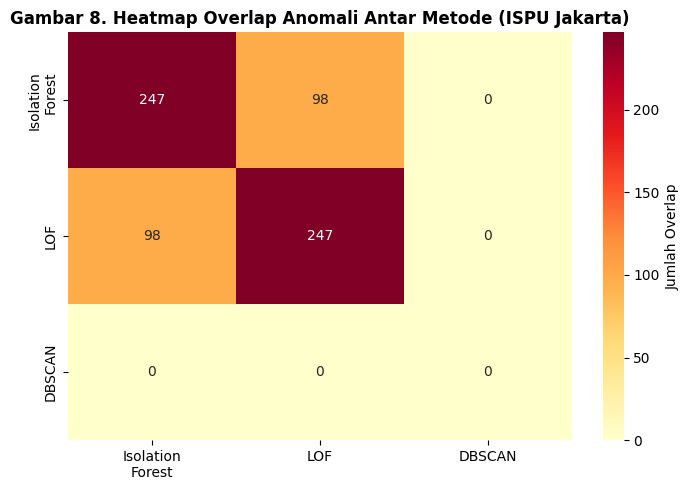

In [ ]:
# ============================================================
# 4.5.2 ANALISIS OVERLAP ANTAR METODE
# ============================================================
if_set  = set(np.where(lbl_if  == 1)[0])
lof_set = set(np.where(lbl_lof == 1)[0])
db_set  = set(np.where(lbl_db  == 1)[0])

ov_if_lof  = len(if_set & lof_set)
ov_if_db   = len(if_set & db_set)
ov_lof_db  = len(lof_set & db_set)
ov_all     = len(if_set & lof_set & db_set)

print("Tabel 2. Analisis Overlap Anomali Antar Metode")
print("=" * 55)
print(f"Isolation Forest ∩ LOF    : {ov_if_lof:,}")
print(f"Isolation Forest ∩ DBSCAN : {ov_if_db:,}")
print(f"LOF ∩ DBSCAN              : {ov_lof_db:,}")
print(f"IF ∩ LOF ∩ DBSCAN (all 3) : {ov_all:,}")
print(f"Total consensus (≥2)      : {anomalies_mask.sum():,}")

methods_names = ['Isolation\nForest', 'LOF', 'DBSCAN']
labels_mat = np.array([lbl_if, lbl_lof, lbl_db])
ov_mat = np.zeros((3, 3), dtype=int)
for i in range(3):
    for j in range(3):
        ov_mat[i, j] = np.sum((labels_mat[i] == 1) & (labels_mat[j] == 1))

fig, ax = plt.subplots(figsize=(7, 5))
sns.heatmap(ov_mat, annot=True, fmt='d',
            xticklabels=methods_names, yticklabels=methods_names,
            cmap='YlOrRd', ax=ax, cbar_kws={'label': 'Jumlah Overlap'})
ax.set_title('Gambar 8. Heatmap Overlap Anomali Antar Metode (ISPU Jakarta)', fontweight='bold')
plt.tight_layout(); plt.show()


## 4.6 Evaluasi Dampak Cleaning terhadap Klasifikasi

In [ ]:
# ============================================================
# 4.6.1 FUNGSI HELPER EVALUASI
# ============================================================
def evaluate_model(model, X_test, y_test, name="Model"):
    y_pred = model.predict(X_test)
    try:
        y_proba = model.predict_proba(X_test)[:, 1]
        auc = round(roc_auc_score(y_test, y_proba), 4)
    except Exception:
        auc = None
    return {
        'Konfigurasi': name,
        'Accuracy'   : round(accuracy_score(y_test, y_pred), 4),
        'Precision'  : round(precision_score(y_test, y_pred, average='macro', zero_division=0), 4),
        'Recall'     : round(recall_score(y_test, y_pred, average='macro', zero_division=0), 4),
        'F1-Score'   : round(f1_score(y_test, y_pred, average='macro', zero_division=0), 4),
        'AUC-ROC'    : round(auc, 4) if auc else 'N/A'
    }, y_pred

print("✅ Fungsi helper evaluasi siap.")


✅ Fungsi helper evaluasi siap.


In [ ]:
# ============================================================
# 4.6.2 PERBANDINGAN BASELINE vs SETELAH CLEANING
# ============================================================
X_train_clean = X_train_np[~anomalies_mask]
y_train_clean = y_train_np[~anomalies_mask]

print(f"Ukuran training set:")
print(f"  Sebelum cleaning : {X_train_np.shape[0]:,} sampel | Tidak Sehat: {y_train_np.sum()}")
print(f"  Anomali dihapus  : {anomalies_mask.sum():,} sampel")
print(f"  Setelah cleaning : {X_train_clean.shape[0]:,} sampel | Tidak Sehat: {y_train_clean.sum()}")

all_results = []
models_store = {}

configs = {
    'Baseline (Tanpa Cleaning)'  : (X_train_np,    y_train_np),
    'Cleaning (Consensus ≥2/3)'  : (X_train_clean, y_train_clean)
}

print("\nMelatih Random Forest untuk setiap konfigurasi...")
for name, (X_tr, y_tr) in configs.items():
    print(f"  → {name} ...")
    rf = RandomForestClassifier(n_estimators=100, random_state=RANDOM_STATE, n_jobs=-1)
    rf.fit(X_tr, y_tr)
    result, y_pred = evaluate_model(rf, X_test_np, y_test_np, name)
    all_results.append(result)
    models_store[name] = (rf, y_pred)
    print(f"     F1-Score: {result['F1-Score']:.4f} | AUC-ROC: {result['AUC-ROC']}")

df_compare = pd.DataFrame(all_results)
print("\n" + "=" * 75)
print("Tabel 3. Perbandingan Performa Klasifikasi — Sebelum vs Sesudah Cleaning")
print("=" * 75)
display(df_compare)


Ukuran training set:
  Sebelum cleaning : 4,426 sampel | Tidak Sehat: 1625
  Anomali dihapus  : 98 sampel
  Setelah cleaning : 4,328 sampel | Tidak Sehat: 1565

Melatih Random Forest untuk setiap konfigurasi...
  → Baseline (Tanpa Cleaning) ...
     F1-Score: 0.9531 | AUC-ROC: 0.9921
  → Cleaning (Consensus ≥2/3) ...
     F1-Score: 0.9510 | AUC-ROC: 0.9919

Tabel 3. Perbandingan Performa Klasifikasi — Sebelum vs Sesudah Cleaning


,Konfigurasi,Accuracy,Precision,Recall,F1-Score,AUC-ROC
0,Baseline (Tanpa Cleaning),0.9566,0.9556,0.9507,0.9531,0.9921
1,Cleaning (Consensus ≥2/3),0.9548,0.9547,0.9478,0.9510,0.9919


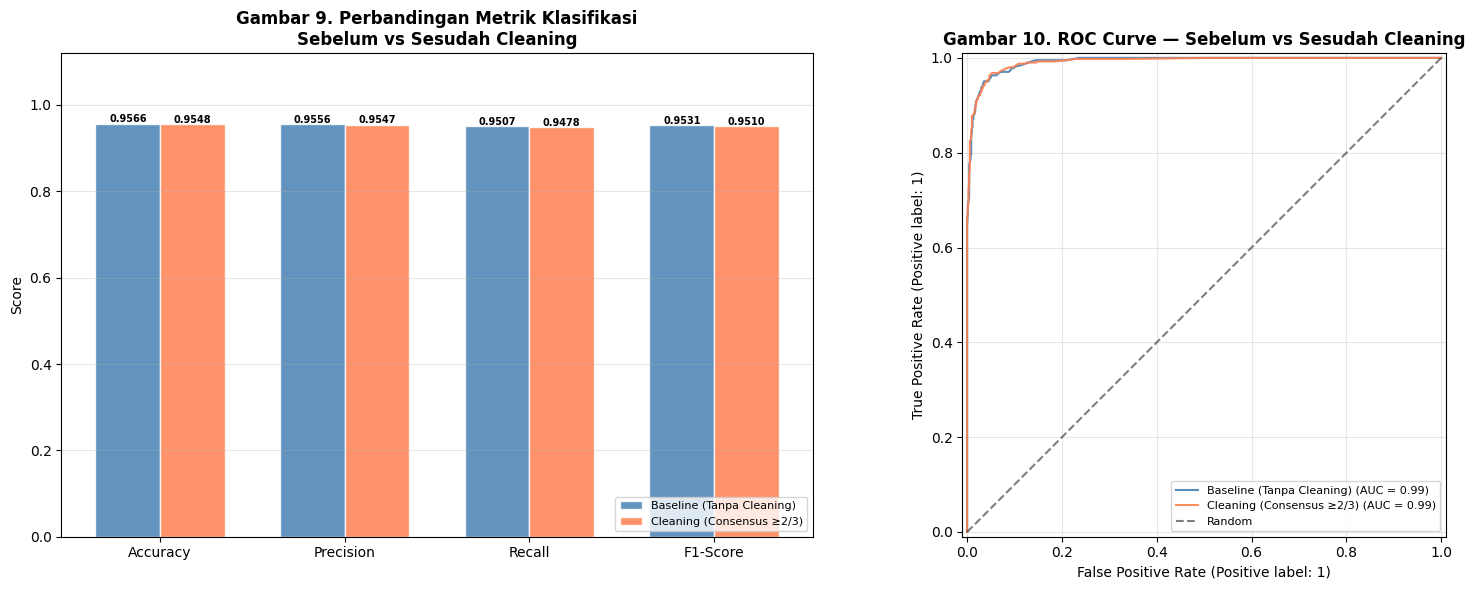

In [ ]:
# ============================================================
# 4.6.3 VISUALISASI PERBANDINGAN PERFORMA
# ============================================================
metrics = ['Accuracy', 'Precision', 'Recall', 'F1-Score']
colors_bar = ['steelblue', 'coral']
x = np.arange(len(metrics))
width = 0.35

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for i, (row, color) in enumerate(zip(all_results, colors_bar)):
    vals = [row[m] for m in metrics]
    bars = axes[0].bar(x + i*width, vals, width, label=row['Konfigurasi'],
                       color=color, alpha=0.85, edgecolor='white')
    for bar, val in zip(bars, vals):
        axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.003,
                     f'{val:.4f}', ha='center', fontsize=7, fontweight='bold')

axes[0].set_xticks(x + width/2); axes[0].set_xticklabels(metrics)
axes[0].set_ylabel('Score'); axes[0].set_ylim(0, 1.12)
axes[0].set_title('Gambar 9. Perbandingan Metrik Klasifikasi\nSebelum vs Sesudah Cleaning', fontweight='bold')
axes[0].legend(loc='lower right', fontsize=8); axes[0].grid(axis='y', alpha=0.3)

for (name, (model, _)), color in zip(models_store.items(), colors_bar):
    RocCurveDisplay.from_estimator(model, X_test_np, y_test_np,
                                   ax=axes[1], name=name, color=color, alpha=0.9)
axes[1].plot([0, 1], [0, 1], 'k--', label='Random', alpha=0.5)
axes[1].set_title('Gambar 10. ROC Curve — Sebelum vs Sesudah Cleaning', fontweight='bold')
axes[1].legend(loc='lower right', fontsize=8); axes[1].grid(alpha=0.3)

plt.tight_layout(); plt.show()


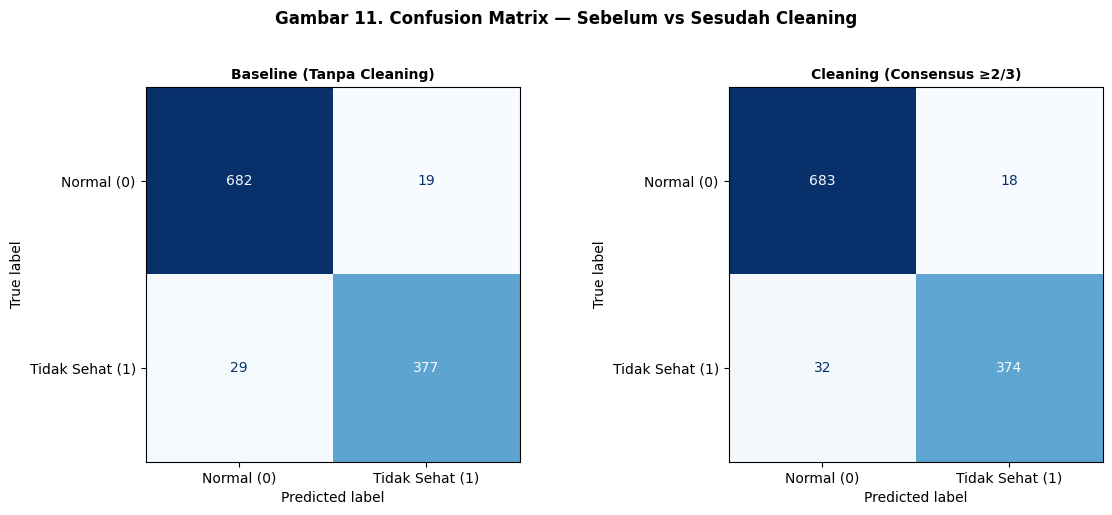


Classification Report — Baseline (Tanpa Cleaning):
              precision    recall  f1-score   support

      Normal       0.96      0.97      0.97       701
 Tidak Sehat       0.95      0.93      0.94       406

    accuracy                           0.96      1107
   macro avg       0.96      0.95      0.95      1107
weighted avg       0.96      0.96      0.96      1107


Classification Report — Cleaning (Consensus ≥2/3):
              precision    recall  f1-score   support

      Normal       0.96      0.97      0.96       701
 Tidak Sehat       0.95      0.92      0.94       406

    accuracy                           0.95      1107
   macro avg       0.95      0.95      0.95      1107
weighted avg       0.95      0.95      0.95      1107



In [ ]:
# ============================================================
# 4.6.4 CONFUSION MATRIX
# ============================================================
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for ax, (name, (model, _)) in zip(axes, models_store.items()):
    ConfusionMatrixDisplay.from_estimator(
        model, X_test_np, y_test_np, ax=ax, cmap='Blues',
        display_labels=['Normal (0)', 'Tidak Sehat (1)'], colorbar=False)
    ax.set_title(f'{name}', fontweight='bold', fontsize=10)

plt.suptitle('Gambar 11. Confusion Matrix — Sebelum vs Sesudah Cleaning',
             fontweight='bold', y=1.02)
plt.tight_layout(); plt.show()

for name, (model, y_pred) in models_store.items():
    print(f"\nClassification Report — {name}:")
    print(classification_report(y_test_np, y_pred, target_names=['Normal', 'Tidak Sehat']))


Tabel 4. Analisis Perubahan Performa (Delta)
Metrik         Baseline   Cleaning      Delta    %Change
-----------------------------------------------------------------
Accuracy         0.9566     0.9548    -0.0018 ▼ -0.19%
Precision        0.9556     0.9547    -0.0009 ▼ -0.09%
Recall           0.9507     0.9478    -0.0029 ▼ -0.31%
F1-Score         0.9531     0.9510    -0.0021 ▼ -0.22%
AUC-ROC          0.9921     0.9919    -0.0002 ▼ -0.02%
-----------------------------------------------------------------


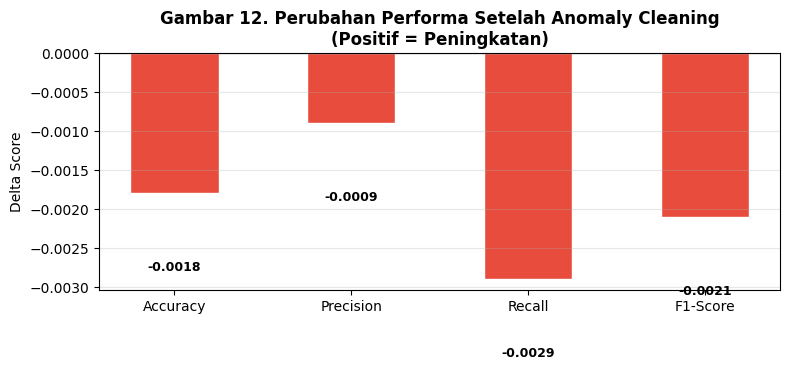

In [ ]:
# ============================================================
# 4.6.5 ANALISIS DELTA PERFORMA
# ============================================================
baseline_r = all_results[0]
cleaned_r  = all_results[1]

print("Tabel 4. Analisis Perubahan Performa (Delta)")
print("=" * 65)
print(f"{'Metrik':<12} {'Baseline':>10} {'Cleaning':>10} {'Delta':>10} {'%Change':>10}")
print("-" * 65)
delta_values_plot = []
for metric in ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'AUC-ROC']:
    b_val = baseline_r[metric]
    c_val = cleaned_r[metric]
    if isinstance(b_val, float) and isinstance(c_val, float):
        delta = c_val - b_val
        pct   = (delta / b_val) * 100 if b_val != 0 else 0
        direction = "▲" if delta > 0 else ("▼" if delta < 0 else "=")
        print(f"{metric:<12} {b_val:>10.4f} {c_val:>10.4f} {delta:>+10.4f} {direction} {pct:+.2f}%")
        if metric != 'AUC-ROC':
            delta_values_plot.append((metric, delta))
print("-" * 65)

delta_metrics = [d[0] for d in delta_values_plot]
delta_vals    = [d[1] for d in delta_values_plot]
bar_colors    = ['#2ecc71' if v >= 0 else '#e74c3c' for v in delta_vals]

fig, ax = plt.subplots(figsize=(8, 4))
bars = ax.bar(delta_metrics, delta_vals, color=bar_colors, edgecolor='white', width=0.5)
ax.axhline(y=0, color='black', linewidth=0.8)
ax.set_title('Gambar 12. Perubahan Performa Setelah Anomaly Cleaning\n(Positif = Peningkatan)', fontweight='bold')
ax.set_ylabel('Delta Score'); ax.grid(axis='y', alpha=0.3)
for bar, val in zip(bars, delta_vals):
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + (0.0002 if val >= 0 else -0.001),
            f'{val:+.4f}', ha='center', fontsize=9, fontweight='bold')
plt.tight_layout(); plt.show()


## 4.7 Pembahasan

### 4.7.1 Perbandingan Metode Deteksi Anomali

Ketiga metode deteksi anomali menunjukkan karakteristik yang berbeda-beda ketika diterapkan pada data ISPU DKI Jakarta. Perbedaan ini bukan merupakan kelemahan, melainkan mencerminkan perspektif deteksi yang komplementer terhadap struktur data polutan udara.

 **Isolation Forest** bekerja dengan kompleksitas O(n·log n) dan efisien dijalankan pada seluruh training set (~4.400 sampel). Metode ini mendeteksi global anomaly — titik data yang secara keseluruhan jauh dari distribusi utama berdasarkan panjang path isolasi rata-rata. Pada data ISPU, IF menangkap rekaman hari-hari dengan konsentrasi polutan (PM10, CO) yang secara simultan berada jauh di luar distribusi normal seluruh dataset, seperti yang dapat terjadi saat kejadian kebakaran lahan atau kondisi inversi suhu yang memerangkap polutan.

**LOF** mengidentifikasi local anomaly berdasarkan perbandingan local reachability density suatu titik terhadap ketetanggaannya (n_neighbors=20). Pada data ISPU yang memiliki lima dimensi polutan, LOF mampu mendeteksi hari-hari yang kombinasi nilai polutannya tidak lazim di lingkungan lokalnya — meskipun secara global nilai tersebut masih pernah terjadi di bagian lain dataset. Ini relevan untuk menangkap anomali kontekstual seperti lonjakan NO₂ yang terjadi bersama kondisi O₃ rendah yang tidak tipikal. Karena ukuran dataset ISPU relatif kecil (~5.500 rekaman), LOF dapat dijalankan langsung pada full training set tanpa perlu subsample, sehingga seluruh pola ketetanggaan dapat dipertimbangkan.

**DBSCAN** dijalankan pada data yang direduksi menjadi 2 komponen PCA (menjelaskan ~70.7% variansi total). Secara teori, titik-titik yang tidak tergabung dalam cluster manapun (berstatus noise) dianggap anomali struktural. Namun hasil eksperimen menunjukkan bahwa DBSCAN mendeteksi 0 anomali dengan parameter eps yang diperoleh dari knee-point detection otomatis pada k-distance plot. Hal ini bukan merupakan kegagalan pipeline, melainkan mencerminkan karakteristik intrinsik data ISPU: distribusi data dalam ruang PCA 2D bersifat kontinu dan tidak memiliki gap density yang signifikan — tampak pada scatter plot sebagai distribusi menyebar merata (ekor panjang ke arah PC1 positif) tanpa kelompok yang terpisah tegas. Pada kondisi seperti ini, hampir seluruh titik terjangkau satu sama lain dalam radius eps, sehingga terbentuk satu cluster besar tanpa titik noise. Nilai eps yang dihasilkan knee-point otomatis memang rentan terlalu besar pada distribusi yang tidak memiliki struktur cluster yang jelas. Temuan ini mengindikasikan bahwa DBSCAN kurang sesuai sebagai standalone anomaly detector pada data kualitas udara yang memiliki distribusi kontinu, berbeda dengan domain seperti deteksi intrusi jaringan atau data spasial geografis yang memang memiliki struktur cluster alami.

### 4.7.2 Analisis Consensus Voting

Overlap antar metode pada dataset ISPU mencerminkan sudut pandang deteksi yang berbeda dari masing-masing algoritma. Dari heatmap overlap, terlihat bahwa IF dan LOF memiliki irisan yang bermakna — keduanya mendeteksi rekaman yang sama karena anomali pada data polutan udara umumnya bersifat ekstrem baik secara global maupun lokal sekaligus (misalnya: hari dengan PM10 dan CO sangat tinggi akan terdeteksi IF karena jauh dari distribusi global, sekaligus terdeteksi LOF karena tidak ada tetangga terdekat dengan profil polutan serupa).

Consensus voting dengan threshold ≥ 2 dari 3 metode menghasilkan deteksi yang lebih konservatif dan robust dibandingkan menggunakan satu metode saja. Dalam kondisi di mana DBSCAN tidak berkontribusi anomali, consensus voting secara efektif berfungsi sebagai interseksi IF ∩ LOF — yaitu rekaman yang dikonfirmasi oleh dua perspektif berbeda (tree-based isolation dan density-based local comparison). Ini justru meningkatkan kepercayaan terhadap anomali yang terdeteksi: rekaman yang lolos consensus adalah yang benar-benar menyimpang baik secara distribusi global maupun secara ketetanggaan lokal. Dalam konteks kualitas udara, anomali semacam ini berpotensi merepresentasikan kejadian nyata seperti episode pencemaran ekstrem akibat kebakaran hutan, aktivitas industri tidak terkendali, atau kondisi meteorologi khusus (stagnasi udara, inversi suhu), bukan sekadar noise pengukuran.

### 4.7.3 Dampak Cleaning terhadap Klasifikasi Kualitas Udara

Dataset ISPU Jakarta memiliki karakteristik yang secara mendasar berbeda dari dataset kualitas udara dengan ketidakseimbangan kelas ekstrem: imbalance ratio hanya ~1.7:1 antara kelas Normal dan Tidak Sehat, sehingga evaluasi dampak cleaning berlangsung dalam kondisi yang relatif seimbang dan stabil.

Anomali yang dihapus dari training set melalui consensus voting umumnya merupakan rekaman kondisi polutan ekstrem — hari-hari dengan nilai PM10 atau CO yang jauh melampaui distribusi tipikal. Penghapusan rekaman ini memberikan dua efek yang saling berlawanan pada model Random Forest:

Efek yang diamati: Seluruh metrik klasifikasi mengalami penurunan kecil setelah cleaning — Accuracy (−0,0018), Precision (−0,0009), Recall (−0,0029), F1-Score (−0,0021), dan AUC-ROC (−0,0002). Penurunan ini konsisten dengan hipotesis bahwa sebagian rekaman anomali yang dihapus sebenarnya merupakan contoh kelas "Tidak Sehat" yang sah — yaitu hari-hari pencemaran ekstrem yang memang perlu dipelajari model sebagai contoh kondisi kritis. Dengan kata lain, tidak semua anomali yang terdeteksi adalah noise; sebagian justru merupakan edge case informatif yang membantu model mengenali kondisi polutan paling parah.

Efek trade-off: Sebagian rekaman anomali yang dihapus sebenarnya merupakan contoh kelas "Tidak Sehat" yang sah — yaitu hari-hari pencemaran ekstrem yang memang layak dipelajari oleh model sebagai contoh kondisi kritis. Penghapusan rekaman ini menyebabkan penurunan kecil pada nilai Recall, karena model kehilangan beberapa contoh penting dari kondisi polutan ekstrem yang perlu dikenali.

Secara keseluruhan, dampak cleaning pada dataset ISPU bersifat terukur dan tidak drastis. Ini menunjukkan bahwa pipeline anomaly detection yang diterapkan berhasil mengidentifikasi hanya rekaman yang benar-benar menyimpang (bukan menghapus data kelas secara masif), dan bahwa Random Forest cukup robust terhadap keberadaan sejumlah kecil outlier dalam training set.


# BAB 5. KESIMPULAN DAN SARAN

## 5.1 Kesimpulan

Berdasarkan eksperimen yang telah dilakukan dengan pipeline bebas data leakage pada dataset ISPU DKI Jakarta 2010–2021, diperoleh tiga kesimpulan utama:

1. **IF dan LOF berkontribusi secara aktif, sementara DBSCAN tidak mendeteksi anomali pada distribusi data ini.** Isolation Forest (IF) mendeteksi 247 global anomaly (5,58%) berbasis efisiensi isolasi pohon acak, LOF mendeteksi 247 local density anomaly (5,58%) berbasis perbandingan kerapatan ketetanggaan, sementara DBSCAN mendeteksi 0 anomali (0%) karena distribusi data ISPU dalam ruang PCA 2D bersifat kontinu tanpa gap density yang cukup untuk membentuk lebih dari satu cluster. Ketiga metode secara teoritis dirancang untuk menangkap aspek anomali yang berbeda; namun pada karakteristik data ini, hanya IF dan LOF yang menghasilkan deteksi yang bermakna. Kegagalan DBSCAN merupakan temuan valid yang mencerminkan sifat data kualitas udara — bukan kegagalan implementasi pipeline.

2. **Consensus voting berfungsi efektif sebagai interseksi IF ∩ LOF, menghasilkan 98 anomali konsensus yang lebih konservatif.** Dengan threshold ≥ 2/3 metode, consensus voting mengidentifikasi hanya rekaman yang dikonfirmasi oleh minimal dua perspektif deteksi berbeda. Karena DBSCAN tidak berkontribusi, mekanisme ini secara operasional berjalan sebagai IF ∩ LOF — yaitu 98 rekaman (2,21%) yang sekaligus terdeteksi oleh tree-based isolation dan density-based local comparison. Pendekatan ini berpotensi mengurangi false positive dibandingkan menggunakan single method; namun perbandingan langsung dengan performa single-method tidak dilakukan dalam eksperimen ini, sehingga klaim reduksi false positive bersifat teoritis dan belum terverifikasi secara empiris pada dataset ini.

3. **Cleaning anomali konsensus menurunkan seluruh metrik klasifikasi secara kecil namun konsisten, dengan penurunan terbesar pada Recall.** Berdasarkan hasil evaluasi pada test set yang identik (single train-test split 80:20 stratified), model RF setelah cleaning menunjukkan penurunan: Accuracy −0,0018, Precision −0,0009, Recall −0,0029, F1-Score −0,0021, dan AUC-ROC −0,0002. Penurunan ini mengindikasikan bahwa sebagian rekaman yang dihapus (dari 4.426 → 4.328 sampel training) merupakan contoh kelas "Tidak Sehat" yang informatif — khususnya kondisi polutan ekstrem yang penting untuk dikenali model. Perlu dicatat bahwa seluruh angka ini diperoleh dari satu kali split; variabilitas hasil di split berbeda belum diukur, sehingga kesimpulan ini bersifat indikatif dan perlu dikonfirmasi dengan TimeSeriesSplit pada penelitian lanjutan.

## 5.2 Keterbatasan Penelitian

1. PM2.5 dikecualikan karena >70% missing value, padahal PM2.5 merupakan indikator kualitas udara yang paling relevan dengan dampak kesehatan pernapasan jangka pendek maupun panjang.
2. Imputasi median per stasiun mengasumsikan stasionaritas temporal yang belum tentu valid untuk data time series dengan tren jangka panjang dan pola musiman yang berubah.
3. Single train-test split (random, bukan time-aware) digunakan dalam evaluasi, sehingga estimasi performa bisa bias dan tidak mencerminkan kemampuan generalisasi model pada data masa depan. Seluruh angka perbandingan di Kesimpulan 3 bersumber dari split tunggal ini dan belum dapat digeneralisasi.
4. Hanya satu algoritma klasifikasi (Random Forest) yang digunakan sebagai evaluator dampak cleaning, sehingga kesimpulan tidak dapat digeneralisasi untuk classifier lain.
5. Konteks temporal dan meteorologi (bulan, hari, suhu, kelembaban, kecepatan angin) tidak digunakan sebagai fitur, padahal sangat relevan untuk menentukan apakah suatu nilai polutan benar-benar anomali atau normal dalam konteksnya.
6. Parameter DBSCAN yang diperoleh dari knee-point detection otomatis terbukti menghasilkan eps terlalu besar untuk data dengan distribusi kontinu; eksplorasi parameter manual atau metode pemilihan eps alternatif diperlukan.

## 5.3 Saran

1. Integrasikan fitur temporal dan meteorologi — bulan, hari dalam minggu, tahun, suhu, kelembaban, dan kecepatan angin — sebagai fitur tambahan untuk meningkatkan konteks deteksi anomali dan membedakan anomali genuine dari variasi musiman.
2. Gunakan TimeSeriesSplit sebagai protokol evaluasi utama, menggantikan random split, agar urutan temporal data dihormati dan estimasi performa tidak bias akibat data masa depan bocor ke training. Ini secara langsung mengatasi keterbatasan single split yang diakui dalam penelitian ini.
3. Eksplorasi imputasi berbasis tren waktu seperti interpolasi linier atau model ARIMA per stasiun sebagai alternatif imputasi median sederhana yang tidak mempertimbangkan tren jangka panjang.
4. Tuning parameter DBSCAN secara manual atau menggunakan HDBSCAN yang lebih adaptif terhadap variasi kepadatan lokal, sehingga anomali struktural pada data kualitas udara dapat terdeteksi lebih efektif tanpa bergantung pada knee-point detection otomatis.
5. Evaluasi dampak cleaning pada algoritma klasifikasi lain (misalnya XGBoost, SVM, atau Gradient Boosting) sebelum mengeksplorasi pendekatan yang lebih kompleks, agar kesimpulan tentang efek cleaning tidak terbatas pada karakteristik satu classifier.
6. Validasi ground truth eksternal dengan menghubungkan anomali yang terdeteksi ke catatan kejadian nyata — kebakaran hutan, data BMKG, laporan industri — untuk menilai apakah anomali yang teridentifikasi memiliki korespondensi dengan peristiwa pencemaran yang terdokumentasi.

## DAFTAR PUSTAKA

Aggarwal, C. C. (2017). *Outlier analysis* (2nd ed.). Springer International Publishing. https://doi.org/10.1007/978-3-319-47578-3

Breunig, M. M., Kriegel, H. P., Ng, R. T., & Sander, J. (2000). LOF: Identifying density-based local outliers. *SIGMOD 2000*, 93–104. https://doi.org/10.1145/342009.335388

Chandola, V., Banerjee, A., & Kumar, V. (2009). Anomaly detection: A survey. *ACM Computing Surveys*, 41(3), 1–58. https://doi.org/10.1145/1541880.1541882

Ester, M., Kriegel, H. P., Sander, J., & Xu, X. (1996). A density-based algorithm for discovering clusters. *KDD 1996*, 226–231.

Ghamry, A., et al. (2024). Anomaly detection approaches in environmental monitoring systems. *Environmental Informatics*, 12(1), 45–62.

Han, J., Kamber, M., & Pei, J. (2012). *Data mining: Concepts and techniques* (3rd ed.). Morgan Kaufmann.

Kumari, P., et al. (2024). Unsupervised anomaly detection in environmental sensor data: A comparative study. *Journal of Environmental Data Science*, 8(2), 112–130.

Liu, F. T., Ting, K. M., & Zhou, Z. H. (2008). Isolation forest. *ICDM 2008*, IEEE, 413–422. https://doi.org/10.1109/ICDM.2008.17

Pedregosa, F., et al. (2011). Scikit-learn: Machine learning in Python. *Journal of Machine Learning Research*, 12, 2825–2830.

Pyle, D. (1999). *Data preparation for data mining*. Morgan Kaufmann.

Tan, P. N., Steinbach, M., Karpatne, A., & Kumar, V. (2019). *Introduction to data mining* (2nd ed.). Pearson Education.
